# FH 04 — Final Holdout Diagnostics

Visualize forecasting residuals and Peak-Risk discrimination on the untouched 2025 test period.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
CONFIG_PATH = PROJECT_ROOT / "configs" / "final_holdout_2025.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/final_holdout_2025.yaml')

In [3]:
# Import functions to run holdout
from src.ontario_peak_risk.final_holdout.plotting import (
    rf_actual_vs_predicted_daily,
    rf_residual_distribution,
    rf_mae_by_horizon,
    xgb_pr_curve,
    xgb_roc_curve,
    xgb_confusion_matrix,
    xgb_metric_by_horizon,
)

In [4]:
from src.ontario_peak_risk.final_holdout.plotting import (
    rf_actual_vs_predicted_daily_enhanced,
    rf_residual_vs_predicted_enhanced,
    xgb_confusion_matrix_enhanced,
    xgb_pr_curve_enhanced,
    xgb_roc_curve_enhanced,
)

In [5]:
# Recovery results of the models
OUT = PROJECT_ROOT / "outputs" / "final_holdout_2025"
REP = PROJECT_ROOT / "reports" / "final_holdout_2025"

rf_pred = pd.read_parquet(OUT / "rf_2025_holdout_predictions.parquet")
xgb_pred = pd.read_parquet(OUT / "xgb_2025_holdout_predictions.parquet")
rf_h = pd.read_csv(REP / "FH_02_rf_horizon_metrics.csv")
xgb_h = pd.read_csv(REP / "FH_03_xgb_horizon_metrics.csv")




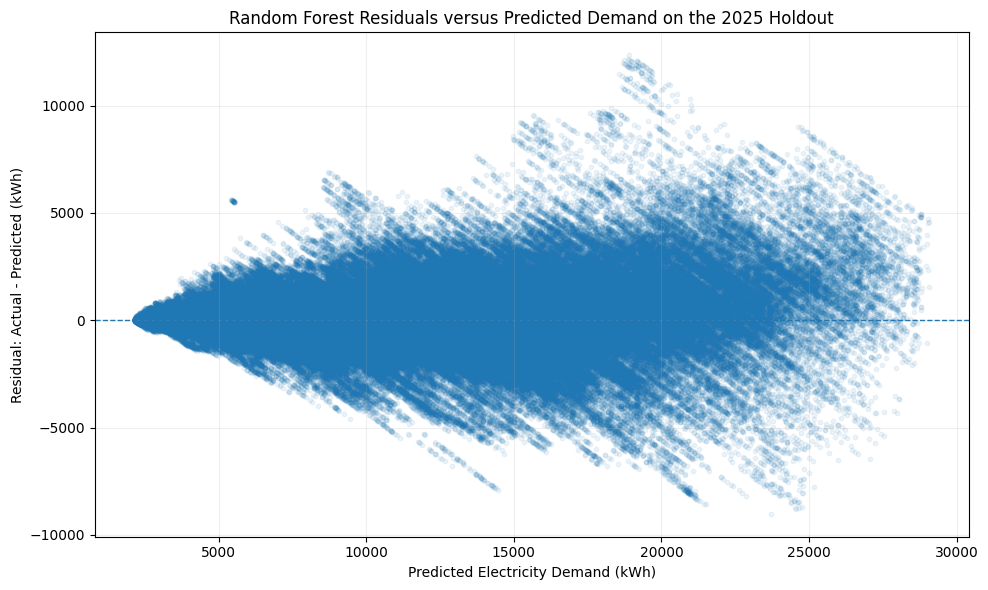

In [6]:
# Random Forest - Residuals vs Predicted Demand

rf_residuals = rf_pred.copy()

# Residual definition:
# positive residual = underprediction
# negative residual = overprediction
rf_residuals["residual"] = (
    rf_residuals["actual"] - rf_residuals["predicted"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    rf_residuals["predicted"],
    rf_residuals["residual"],
    alpha=0.08,
    s=10
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Predicted Electricity Demand (kWh)")
plt.ylabel("Residual: Actual - Predicted (kWh)")
plt.title(
    "Random Forest Residuals versus Predicted Demand "
    "on the 2025 Holdout"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

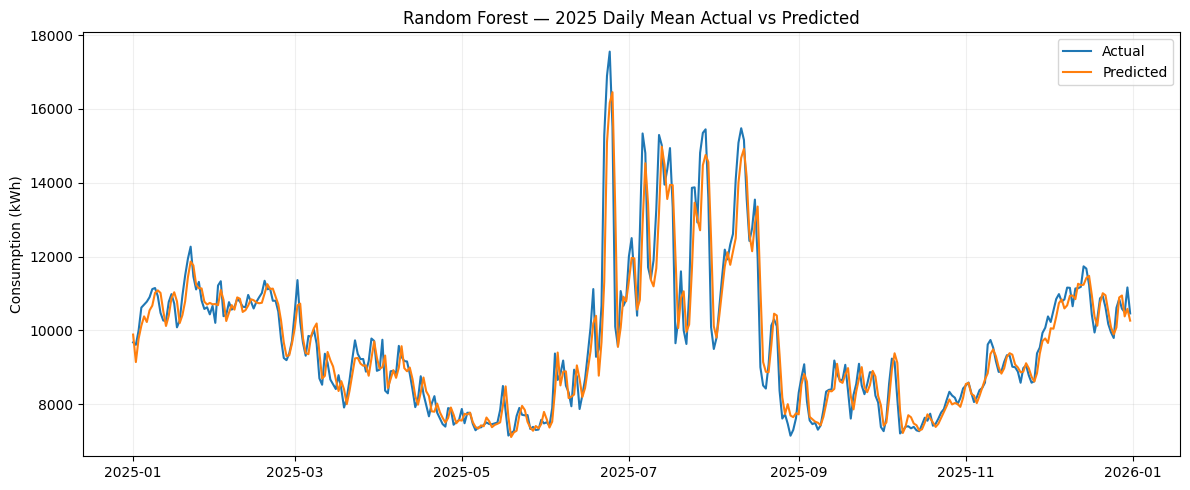

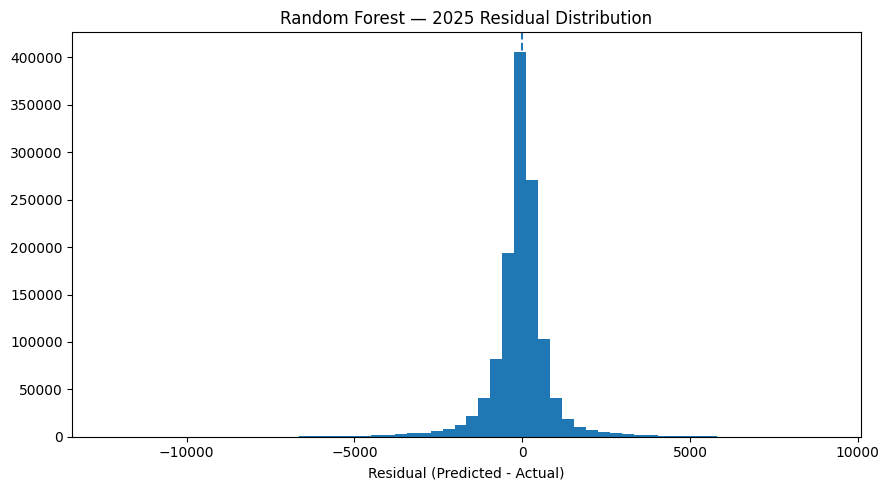

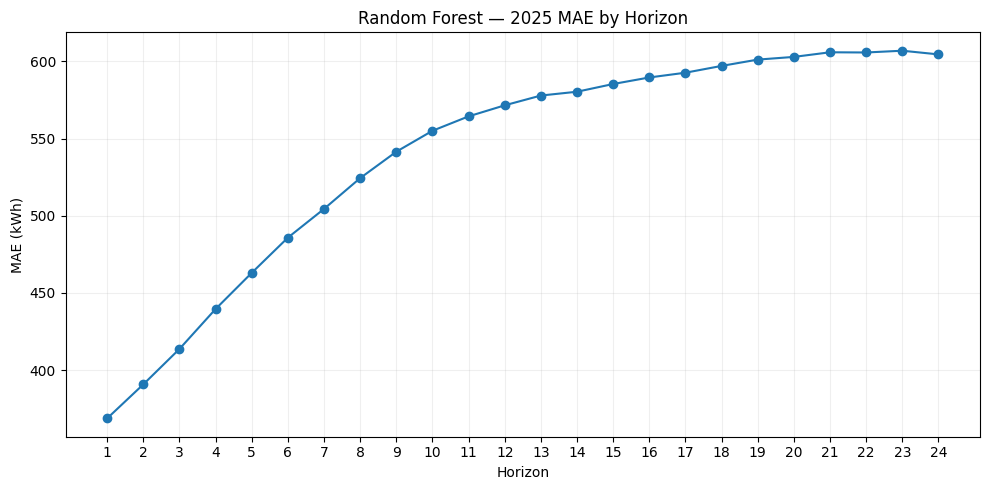

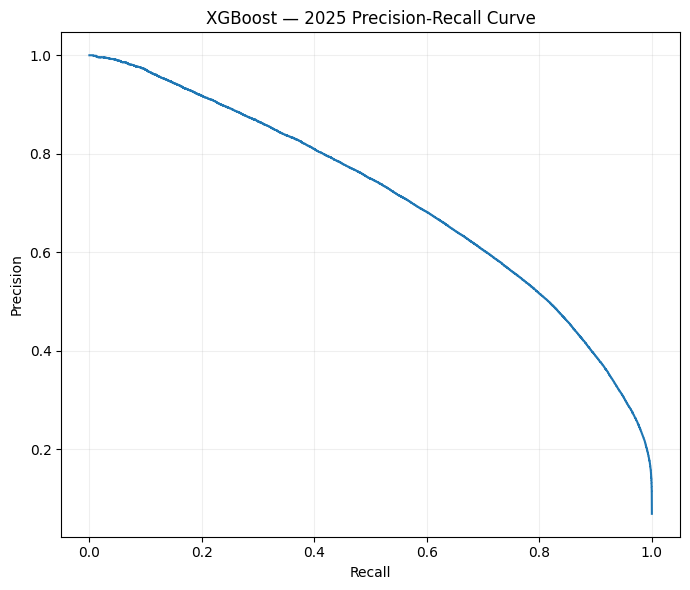

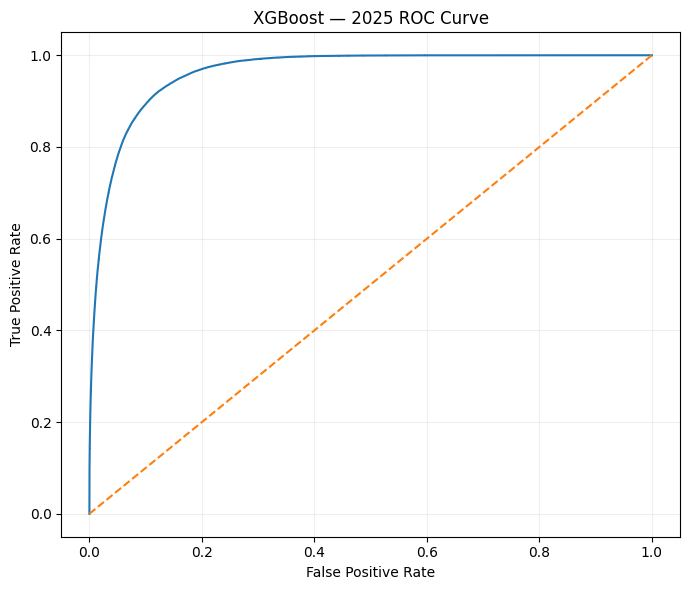

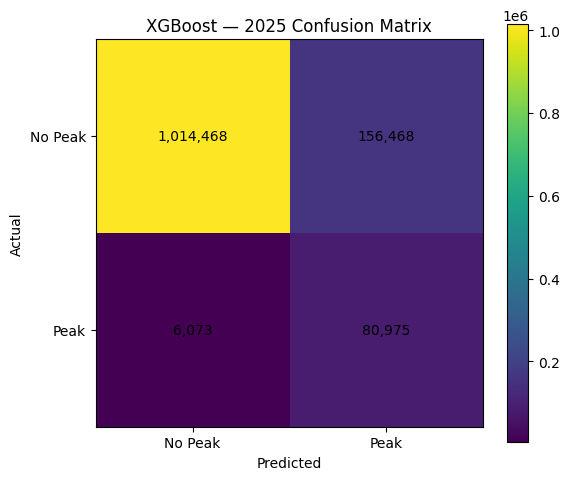

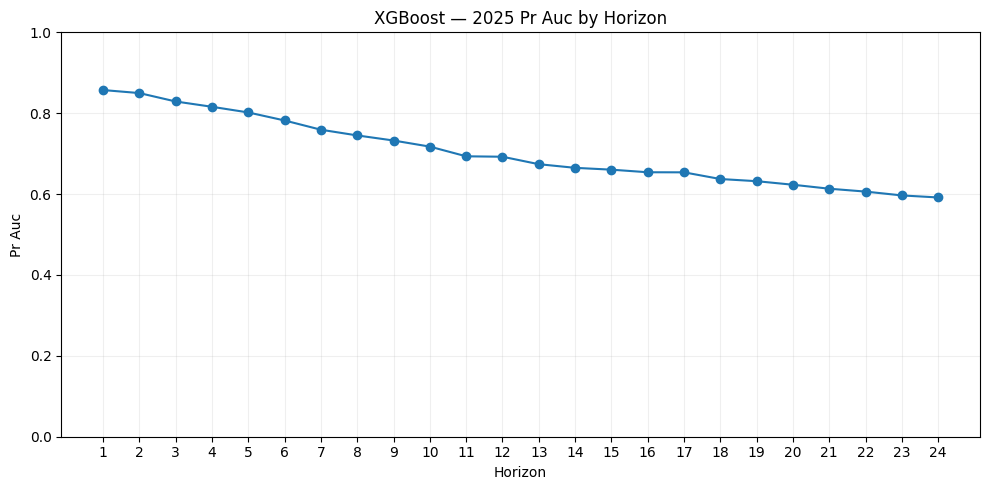

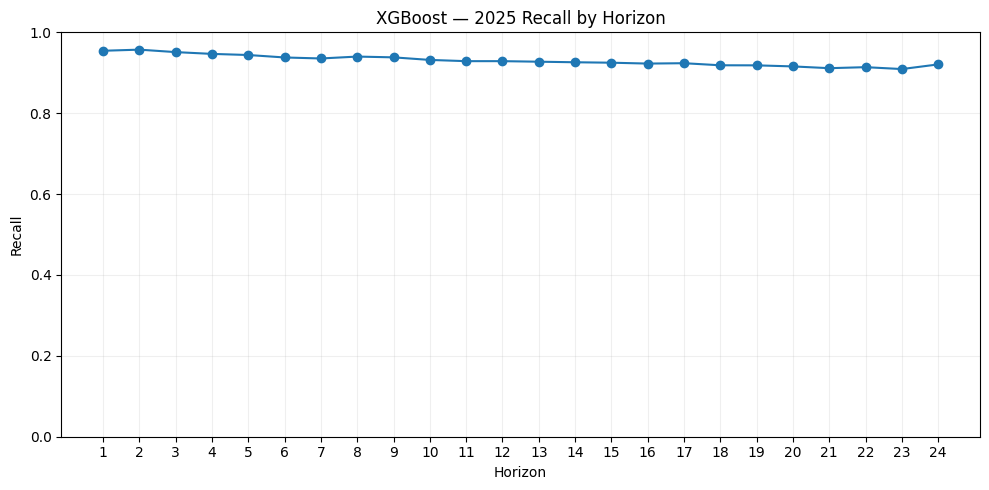

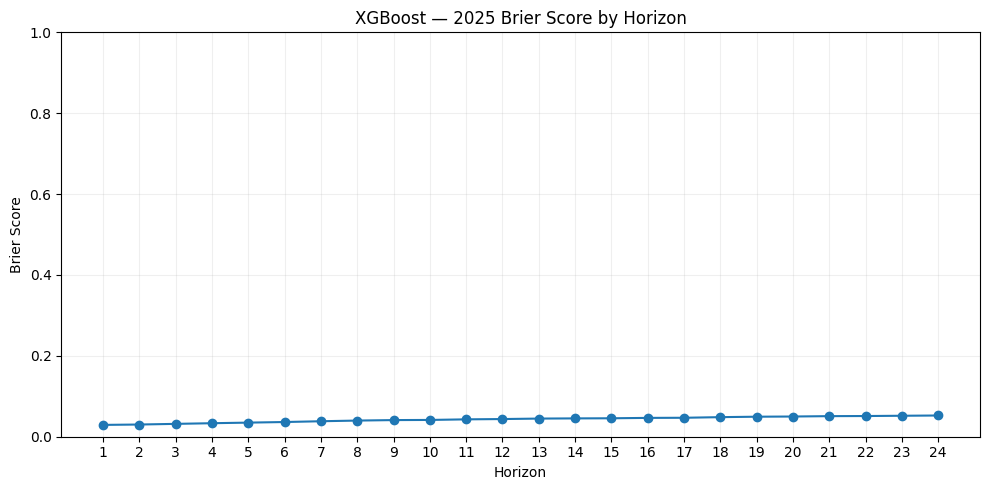

In [7]:
for fig in [
    rf_actual_vs_predicted_daily(rf_pred),
    rf_residual_distribution(rf_pred),
    rf_mae_by_horizon(rf_h),
    xgb_pr_curve(xgb_pred),
    xgb_roc_curve(xgb_pred),
    xgb_confusion_matrix(xgb_pred),
    xgb_metric_by_horizon(xgb_h, "pr_auc"),
    xgb_metric_by_horizon(xgb_h, "recall"),
    xgb_metric_by_horizon(xgb_h, "brier_score"),
]:
    plt.show()

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
CONFIG_PATH = PROJECT_ROOT / "configs" / "final_holdout_2025.yaml"
PROJECT_ROOT, CONFIG_PATH

(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/final_holdout_2025.yaml'))

,fsa,mae,rmse,mape,wape,bias,n_observations
0,L4T,675.502648,1131.097595,5.154385,5.598738,-84.135803,209664
1,M5R,491.139434,732.088743,5.915410,6.054764,8.858665,209664
2,M5S,227.944889,325.341626,5.186579,5.305367,2.970736,209664
3,M6G,683.994487,1038.151040,5.262172,5.437790,-114.627035,209664
4,M9R,412.886419,724.912724,6.339629,6.903557,20.213328,209664
5,M9W,751.669814,1277.437575,4.642693,5.026971,-152.372559,209664


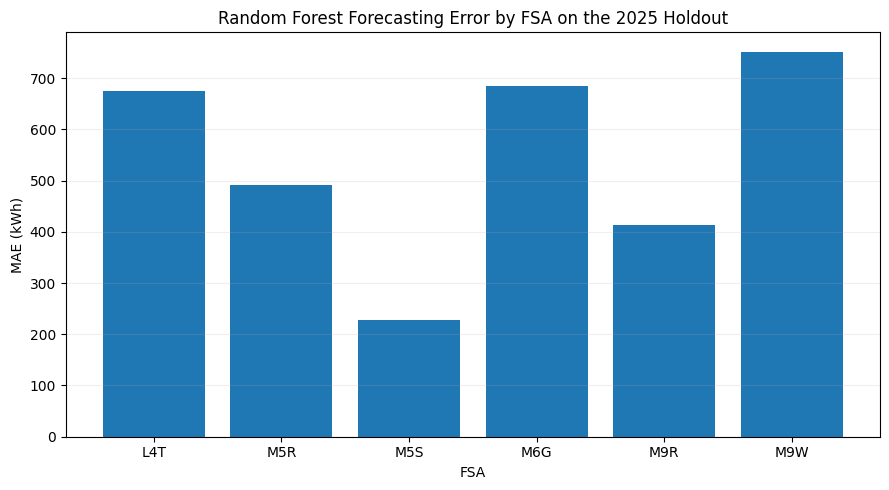

In [10]:


# Adjust ROOT only if it is not already defined in the notebook
REPORT_DIR = PROJECT_ROOT / "reports" / "final_holdout_2025"

rf_fsa = pd.read_csv(REPORT_DIR / "FH_02_rf_fsa_metrics.csv")

display(rf_fsa)

# Sort by FSA for consistent presentation
rf_fsa = rf_fsa.sort_values("fsa")

plt.figure(figsize=(9, 5))

plt.bar(
    rf_fsa["fsa"],
    rf_fsa["mae"]
)

plt.xlabel("FSA")
plt.ylabel("MAE (kWh)")
plt.title(
    "Random Forest Forecasting Error by FSA "
    "on the 2025 Holdout"
)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

,fsa,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc,brier_score,true_negative,false_positive,false_negative,true_positive,actual_peak_rate_pct,predicted_peak_rate_pct,n_observations
0,L4T,0.244990,0.967957,0.391014,0.915963,0.697799,0.976764,0.032690,173243,27277,293,8851,4.361264,17.231380,209664
1,M5R,0.375869,0.854225,0.522036,0.875402,0.651109,0.952199,0.041677,175206,20210,2077,12171,6.795635,15.444235,209664
2,M5S,0.397043,0.814270,0.533802,0.869470,0.638829,0.961308,0.034296,182738,14887,2236,9803,5.742044,11.775984,209664
3,M6G,0.416234,0.964095,0.581440,0.911536,0.816628,0.973369,0.040762,163087,26775,711,19091,9.444635,21.875954,209664
4,M9R,0.307219,0.970625,0.466715,0.914760,0.738016,0.973521,0.037480,169173,27793,373,12325,6.056357,19.134425,209664
5,M9W,0.321559,0.979965,0.484227,0.886266,0.755684,0.965638,0.069792,151021,39526,383,18734,9.117922,27.787317,209664


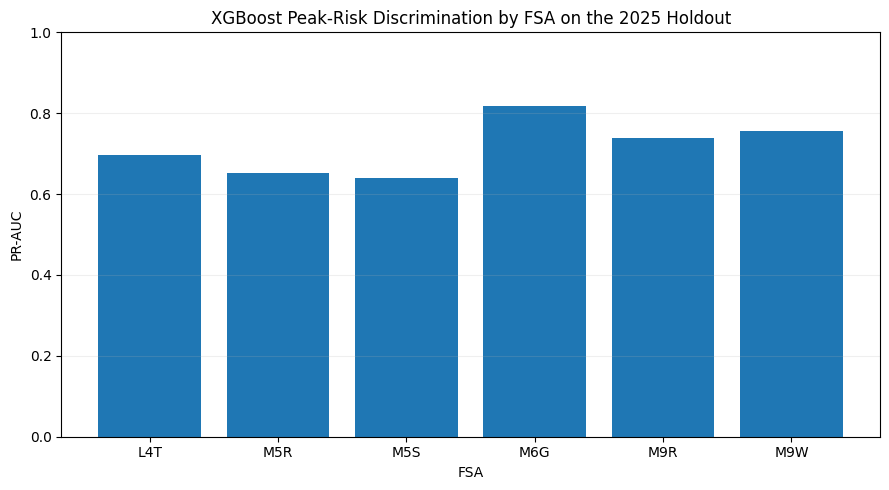

In [11]:
xgb_fsa = pd.read_csv(REPORT_DIR / "FH_03_xgb_fsa_metrics.csv")

display(xgb_fsa)

# Sort by FSA for consistent presentation
xgb_fsa = xgb_fsa.sort_values("fsa")

plt.figure(figsize=(9, 5))

plt.bar(
    xgb_fsa["fsa"],
    xgb_fsa["pr_auc"]
)

plt.xlabel("FSA")
plt.ylabel("PR-AUC")
plt.title(
    "XGBoost Peak-Risk Discrimination by FSA "
    "on the 2025 Holdout"
)

plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

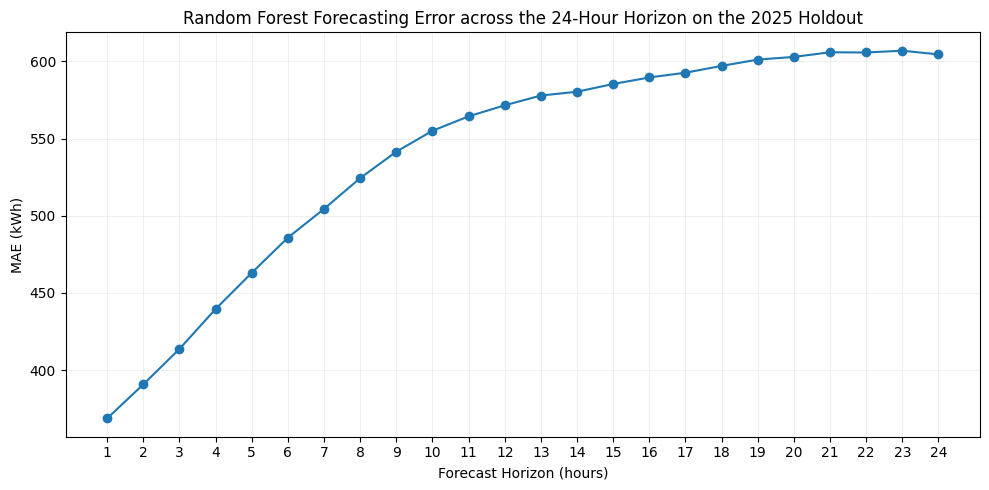

In [12]:
# Random Forest - MAE by Forecast Horizon

rf_h_plot = rf_h.sort_values("horizon").copy()

plt.figure(figsize=(10, 5))

plt.plot(
    rf_h_plot["horizon"],
    rf_h_plot["mae"],
    marker="o"
)

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("MAE (kWh)")
plt.title(
    "Random Forest Forecasting Error across the 24-Hour Horizon "
    "on the 2025 Holdout"
)

plt.xticks(range(1, 25))
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    REP / "FH_04_rf_mae_by_horizon.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

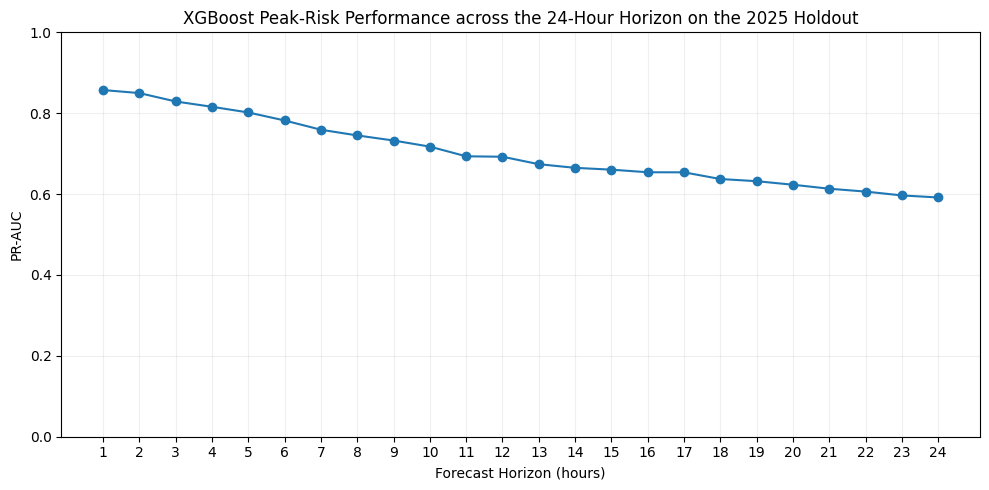

In [13]:
# XGBoost - PR-AUC by Forecast Horizon

xgb_h_plot = xgb_h.sort_values("horizon").copy()

plt.figure(figsize=(10, 5))

plt.plot(
    xgb_h_plot["horizon"],
    xgb_h_plot["pr_auc"],
    marker="o"
)

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("PR-AUC")
plt.title(
    "XGBoost Peak-Risk Performance across the 24-Hour Horizon "
    "on the 2025 Holdout"
)

plt.xticks(range(1, 25))
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    REP / "FH_04_xgb_pr_auc_by_horizon.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

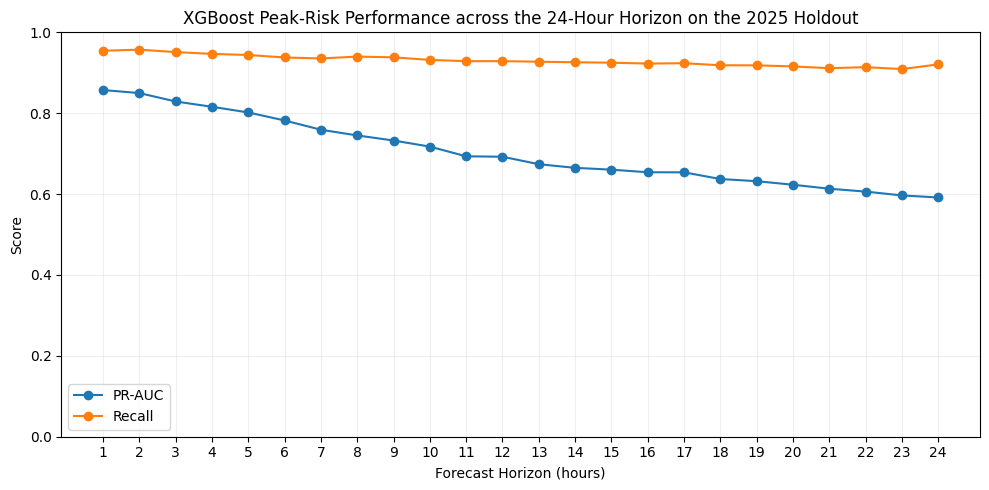

In [14]:
# XGBoost - PR-AUC and Recall by Forecast Horizon

xgb_h_plot = xgb_h.sort_values("horizon").copy()

plt.figure(figsize=(10, 5))

plt.plot(
    xgb_h_plot["horizon"],
    xgb_h_plot["pr_auc"],
    marker="o",
    label="PR-AUC"
)

plt.plot(
    xgb_h_plot["horizon"],
    xgb_h_plot["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Score")
plt.title(
    "XGBoost Peak-Risk Performance across the 24-Hour Horizon "
    "on the 2025 Holdout"
)

plt.xticks(range(1, 25))
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    REP / "FH_04_xgb_pr_auc_recall_by_horizon.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

REPORT_DIR = PROJECT_ROOT / "reports" / "final_holdout_2025"

rf_month = pd.read_csv(
    REPORT_DIR / "FH_02_rf_month_metrics.csv"
)

display(rf_month)
print(rf_month.columns.tolist())

,month,mae,rmse,mape,wape,bias,n_observations
0,1,446.322783,566.152451,4.535317,4.145698,-66.467283,105336
1,2,331.254108,452.954530,3.307912,3.130465,1.720422,96768
2,3,449.144167,594.461850,5.176206,4.853301,-12.350621,107136
3,4,377.248616,541.998412,4.681944,4.528065,30.635754,103680
4,5,282.081359,441.006714,3.722482,3.734323,3.466456,107136
5,6,1039.236692,1703.762455,9.442486,10.268229,-232.173742,103680
6,7,1326.561987,1851.408668,10.522776,10.372939,-300.575798,107136
7,8,775.713030,1192.397560,7.163141,7.214603,63.022300,107136
8,9,413.803782,629.897222,4.781750,4.964704,-14.952991,103680
9,10,304.948108,504.619674,3.885790,3.907304,22.583413,107136


['month', 'mae', 'rmse', 'mape', 'wape', 'bias', 'n_observations']


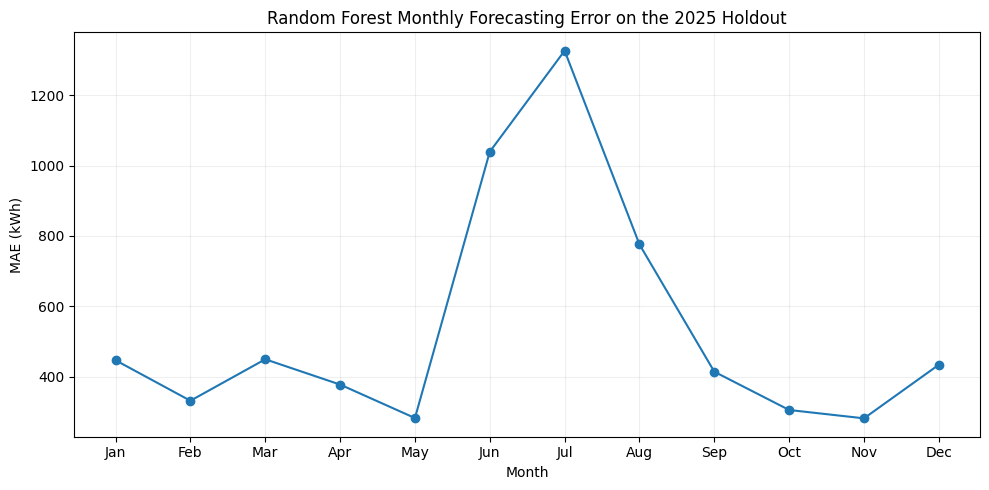

In [16]:
# Random Forest - Monthly MAE on 2025 Holdout

rf_month_plot = rf_month.sort_values("month").copy()

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.plot(
    rf_month_plot["month"],
    rf_month_plot["mae"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("MAE (kWh)")
plt.title(
    "Random Forest Monthly Forecasting Error "
    "on the 2025 Holdout"
)

plt.xticks(
    range(1, 13),
    month_labels
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    REPORT_DIR / "FH_04_rf_monthly_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
xgb_month = pd.read_csv(
    REPORT_DIR / "FH_03_xgb_month_metrics.csv"
)

display(xgb_month)
print(xgb_month.columns.tolist())

,month,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc,brier_score,true_negative,false_positive,false_negative,true_positive,actual_peak_rate_pct,predicted_peak_rate_pct,n_observations
0,1,0.375976,0.977980,0.543144,0.882520,0.803034,0.964692,0.061824,73291,19829,269,11947,11.597175,30.166325,105336
1,2,0.288900,0.991833,0.447463,0.897440,0.755601,0.973092,0.050179,71908,17636,59,7165,7.465278,25.629340,96768
2,3,0.286121,0.942537,0.438983,0.866878,0.650468,0.942705,0.065903,77856,20544,502,8234,8.154122,26.861186,107136
3,4,0.196707,0.589286,0.294956,0.780839,0.361631,0.959672,0.009123,99674,2830,483,693,1.134259,3.397955,103680
4,5,0.052717,0.988636,0.100096,0.972376,0.212718,0.992496,0.005184,102182,4690,3,261,0.246416,4.621229,107136
5,6,0.494666,0.909497,0.640804,0.919085,0.836545,0.979298,0.025789,89420,6868,669,6723,7.129630,13.108603,103680
6,7,0.541520,0.962348,0.693054,0.885219,0.827141,0.956213,0.069812,70071,16641,769,19655,19.063620,33.878435,107136
7,8,0.418383,0.994644,0.589008,0.931325,0.845795,0.983717,0.037128,84891,12909,50,9286,8.714158,20.716659,107136
8,9,0.100651,0.998366,0.182866,0.891322,0.432051,0.970356,0.063410,79394,21838,4,2444,2.361111,23.420139,103680
9,10,0.260704,0.969167,0.410881,0.969017,0.588982,0.992420,0.011147,102638,3298,37,1163,1.120072,4.163866,107136


['month', 'precision', 'recall', 'f1', 'balanced_accuracy', 'pr_auc', 'roc_auc', 'brier_score', 'true_negative', 'false_positive', 'false_negative', 'true_positive', 'actual_peak_rate_pct', 'predicted_peak_rate_pct', 'n_observations']


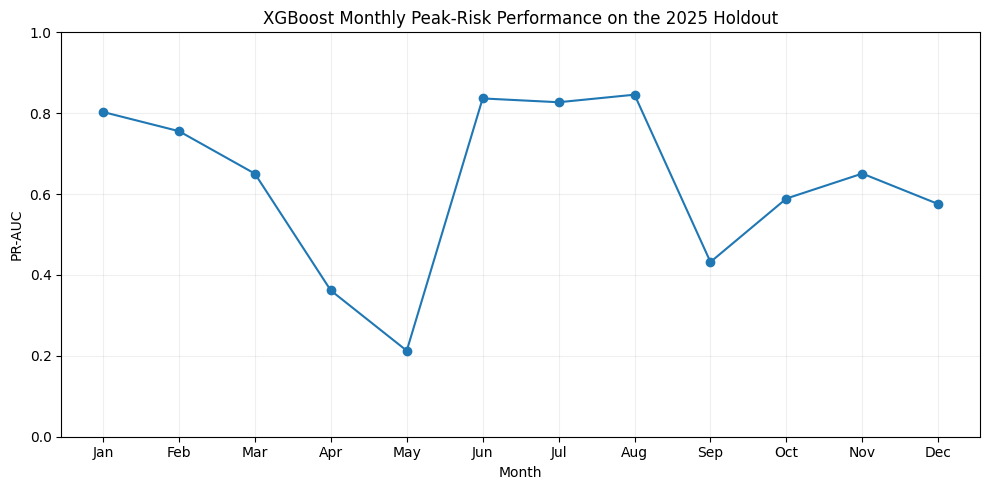

In [18]:
# XGBoost - Monthly PR-AUC on 2025 Holdout

xgb_month_plot = xgb_month.sort_values("month").copy()

plt.figure(figsize=(10, 5))

plt.plot(
    xgb_month_plot["month"],
    xgb_month_plot["pr_auc"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("PR-AUC")
plt.title(
    "XGBoost Monthly Peak-Risk Performance "
    "on the 2025 Holdout"
)

plt.xticks(
    range(1, 13),
    month_labels
)

plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    REPORT_DIR / "FH_04_xgb_monthly_pr_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
print(xgb_month.columns.tolist())

['month', 'precision', 'recall', 'f1', 'balanced_accuracy', 'pr_auc', 'roc_auc', 'brier_score', 'true_negative', 'false_positive', 'false_negative', 'true_positive', 'actual_peak_rate_pct', 'predicted_peak_rate_pct', 'n_observations']


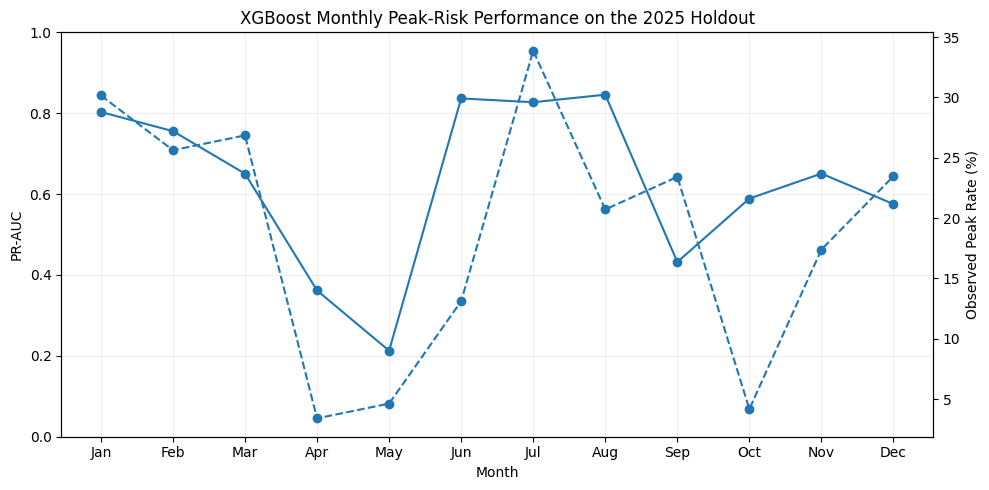

In [20]:
# XGBoost - Monthly PR-AUC and observed Peak rate

xgb_month_plot = xgb_month.sort_values("month").copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    xgb_month_plot["month"],
    xgb_month_plot["pr_auc"],
    marker="o",
    label="PR-AUC"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("PR-AUC")
ax1.set_ylim(0, 1)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()

ax2.plot(
    xgb_month_plot["month"],
    xgb_month_plot["predicted_peak_rate_pct"],
    marker="o",
    linestyle="--",
    label="Observed Peak Rate"
)

ax2.set_ylabel("Observed Peak Rate (%)")

plt.title(
    "XGBoost Monthly Peak-Risk Performance "
    "on the 2025 Holdout"
)

fig.tight_layout()

plt.savefig(
    REPORT_DIR / "FH_04_xgb_monthly_pr_auc_peak_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

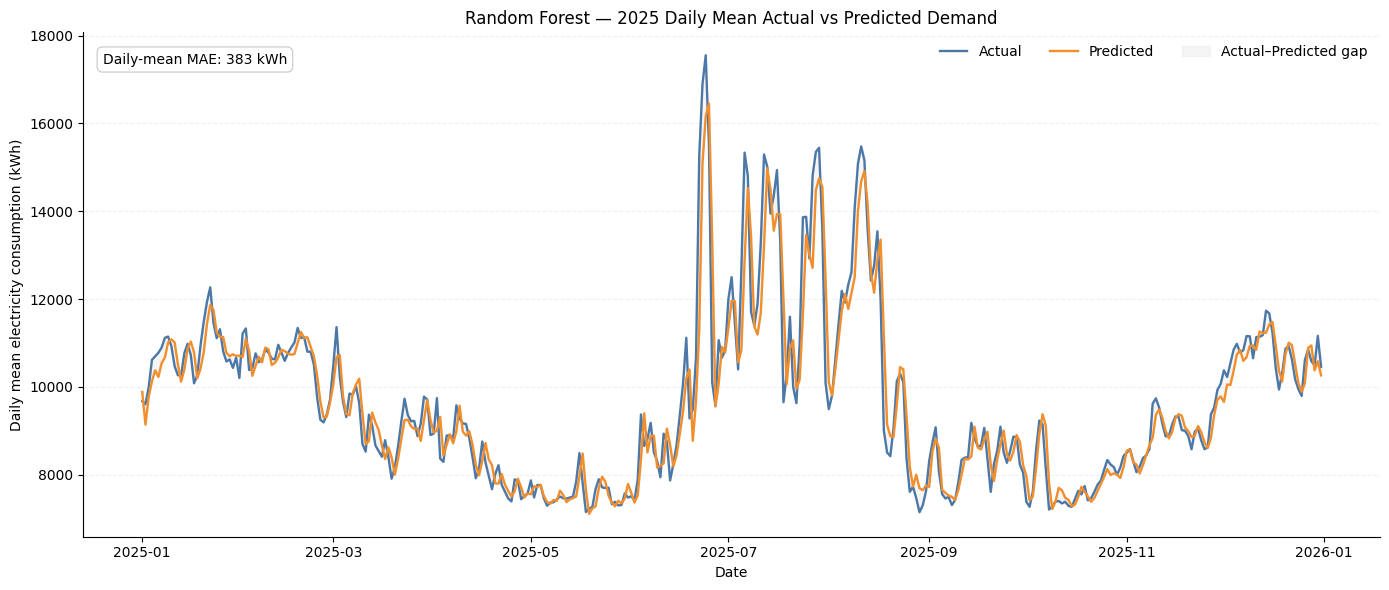

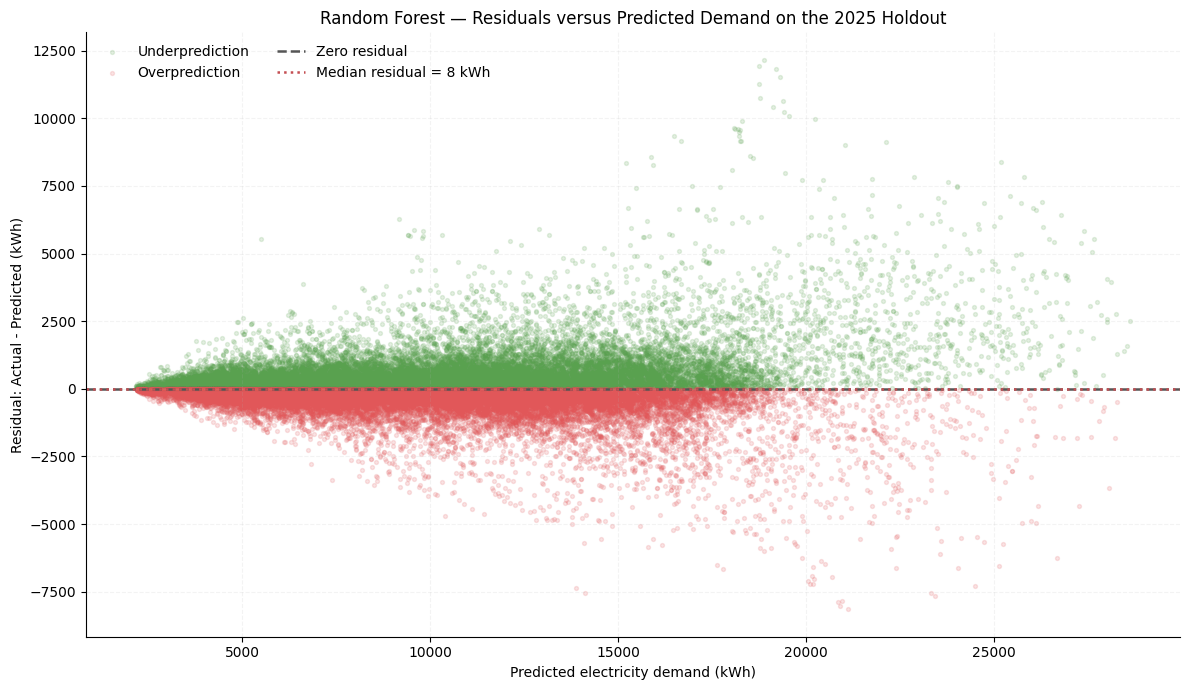

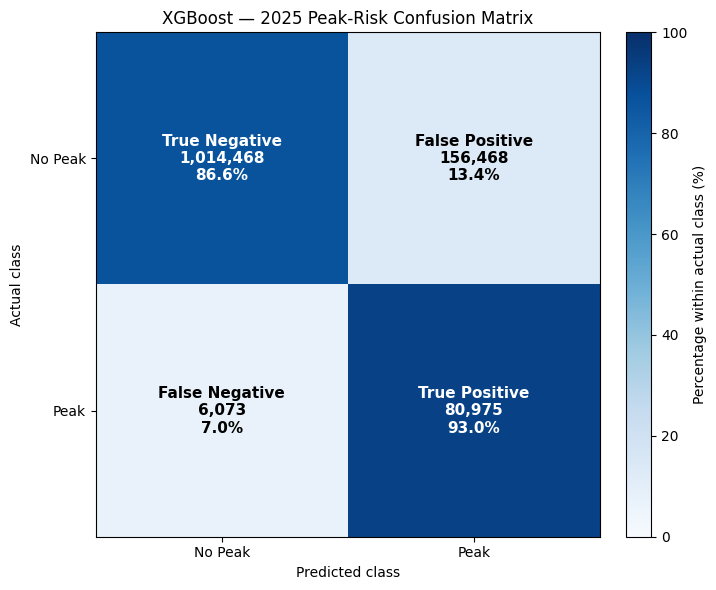

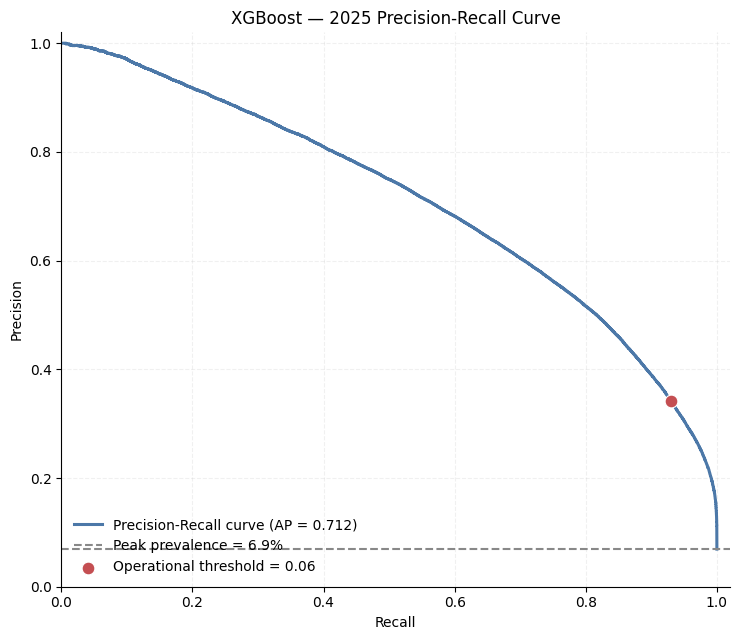

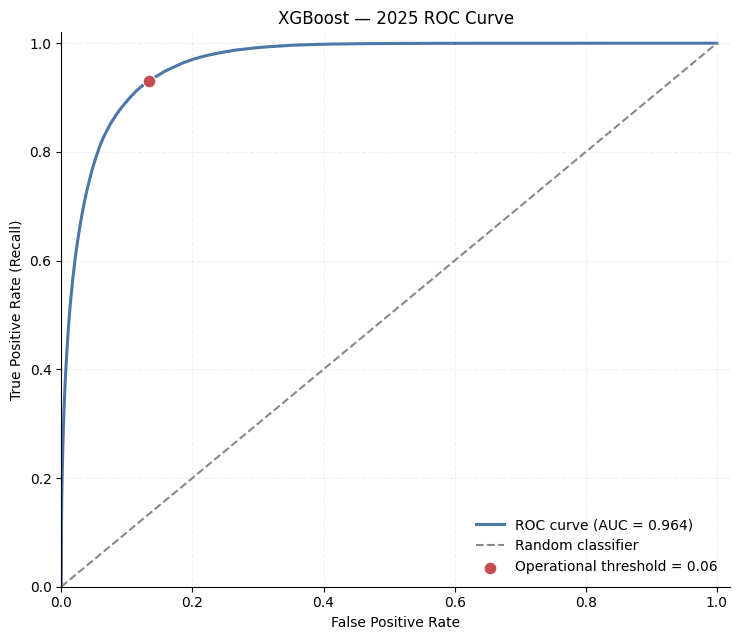

In [21]:
presentation_figures = {
    "FH_04_rf_actual_vs_predicted_daily_enhanced.png":
        rf_actual_vs_predicted_daily_enhanced(rf_pred),

    "FH_04_rf_residual_vs_predicted_enhanced.png":
        rf_residual_vs_predicted_enhanced(rf_pred),

    "FH_04_xgb_confusion_matrix_enhanced.png":
        xgb_confusion_matrix_enhanced(xgb_pred),

    "FH_04_xgb_precision_recall_enhanced.png":
        xgb_pr_curve_enhanced(
            xgb_pred,
            operational_threshold=0.06,
        ),

    "FH_04_xgb_roc_enhanced.png":
        xgb_roc_curve_enhanced(
            xgb_pred,
            operational_threshold=0.06,
        ),
}

In [23]:
for filename, fig in presentation_figures.items():

    fig.savefig(
        REP / filename,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    plt.close(fig)